### Visualize the similarity between DEGs within each of the contrasts

In [2]:
library(tidyverse)
library(reshape2)

In [36]:
plots_dir <- "DESeq2_plots/"
dir.create(plots_dir)

In [12]:
contrasts <- c("development")
num_contrasts <- length(contrasts)

corresponding_contrast_file_names <- c("age_group_fetal_vs_young")

cell_types <- c("Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
              "Fibroblast", "Lymphoid", "LEC", "Myeloid", "Neuronal", "Pericyte", "vSMC")

q_val_threshold <- 0.05
log2_FC_threshold <- 0.5

In [13]:
extract_up_and_down_genes <- function(DE_genes_df, q_val_threshold, log2_FC_threshold) {
    # obtain the number of DE genes that are up and down regulated
    up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
    down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)   

    up_sig_genes <- dim(up_df)[1]
    down_sig_genes <- dim(down_df)[1]

    return(list(up_sig_genes, down_sig_genes))
}

### Iterate through all cell types and create a df with all of the DEG genes

In [14]:
up_list <- list()
down_list <- list()

for (cell_type in cell_types) {

    for (i in 1:num_contrasts) {
        contrast_val <- contrasts[i]
        contrast_file_name <- corresponding_contrast_file_names[i]
        contrast_file_path <- paste0("pydeseq2_results/", cell_type, "_", contrast_file_name, "_results.csv")

        if (file.exists(contrast_file_path)) {
            df <- read.csv(contrast_file_path, row.names = 1)
            # add additional columns
            df$cell_type <- cell_type
            df$contrast <- contrast_val

            # create separate dfs for up and down DEGs
            up_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange >= log2_FC_threshold)
            down_df <- df %>% filter(padj <= q_val_threshold) %>% filter(log2FoldChange <= -log2_FC_threshold)

            up_list[[length(up_list) + 1]] <- up_df
            down_list[[length(down_list) + 1]] <- down_df
        }
    }
}

# combine all up and down genes
up_DEGs_combined_df <- bind_rows(up_list)
down_DEGs_combined_df <- bind_rows(down_list)

In [15]:
dim(up_DEGs_combined_df)
dim(down_DEGs_combined_df)

[1] 17232    11

[1] 15164    11

#### Compute the Jaccard similarity of DEGs for the same contrast, across all cell types. Do this for all 4 contrasts.

In [16]:
jaccard_similarity <- function(set1, set2) {
  length(intersect(set1, set2)) / length(union(set1, set2))
}

In [17]:
# function to compute the Jaccard similarity for all DEGs across cell types in DEG_df, for the specific contrast
compute_jaccard_similarity_for_contrast <- function(contrast_of_interest, DEG_df) {
    
    # filter the df to contrast of interest
    filtered_df <- DEG_df %>%
  filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # iterate through all cell type comparisons
    cell_types <- names(cell_type_gene_list)

    # create matrix to store the Jaccard similarity
    jaccard_matrix <- matrix(0, nrow = length(cell_types), ncol = length(cell_types),
                         dimnames = list(cell_types, cell_types))
    # iterate through all cell types
    for (i in seq_along(cell_types)) {
        for (j in seq_along(cell_types)) {
    jaccard_matrix[i, j] <- jaccard_similarity(cell_type_gene_list[[i]], cell_type_gene_list[[j]])
        }
    }

    # convert the matrix 
    jaccard_df <- melt(jaccard_matrix) %>%
        rename(cell_type_1 = Var1, cell_type_2 = Var2, similarity = value)

    # produce plot
    p1 <- ggplot(jaccard_df, aes(x = cell_type_1, y = cell_type_2, fill = similarity)) +
      geom_tile(color = "white") +
      scale_fill_gradient(low = "white", high = "blue", name = "Jaccard\nSimilarity") +
      theme_minimal() +
      theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 12),
            axis.text.y = element_text(size = 12),
        axis.title.x = element_blank(),
        axis.title.y = element_blank()) +
      labs(title = paste("Jaccard Similarity for", contrast_of_interest))

    # return the Jaccard similarity matrix and plot

    return(list(jaccard_matrix, p1))
}

### Produce jaccard plots for up DEGs

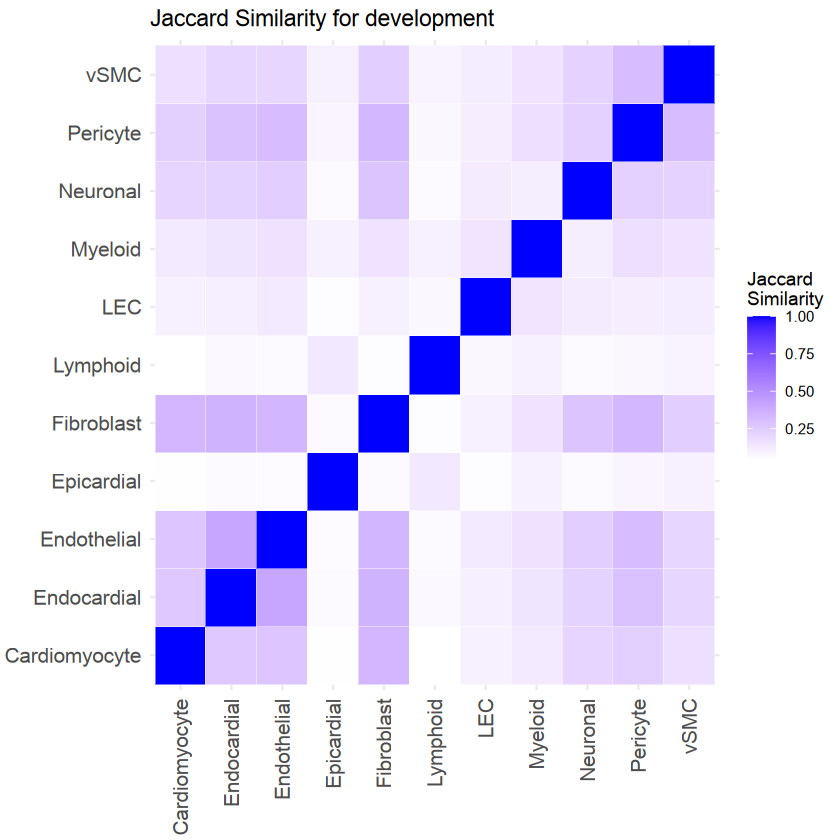

In [18]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "development", DEG_df = up_DEGs_combined_df)
results[[2]]

### Compute Jaccard similarity for down DEGs

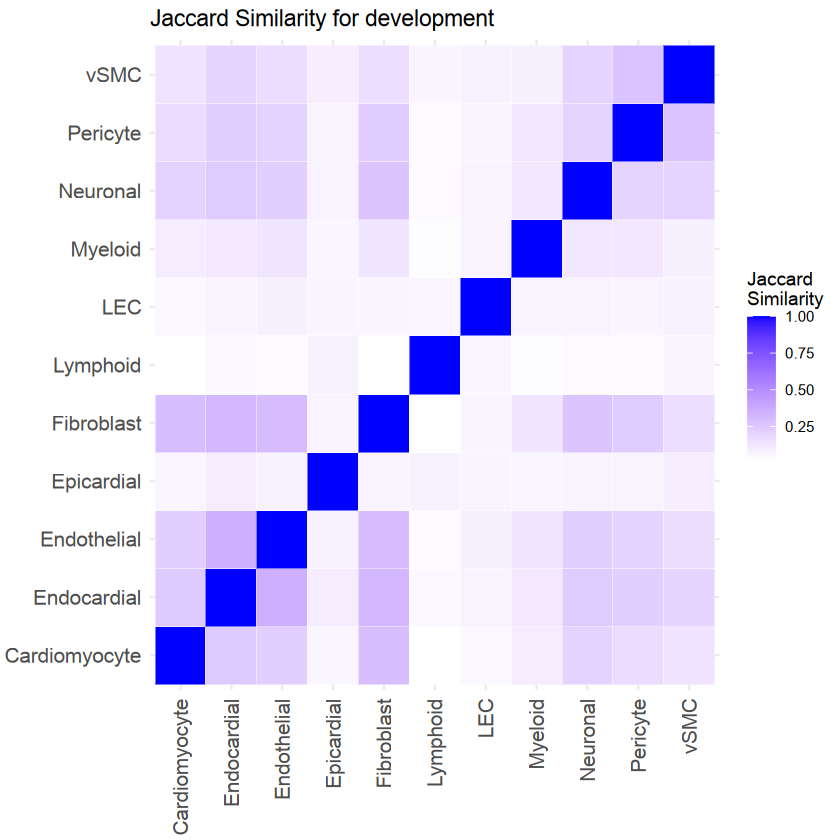

In [19]:
results <- compute_jaccard_similarity_for_contrast(contrast_of_interest = "development", DEG_df = down_DEGs_combined_df)
results[[2]]

### Another analysis is to identify which genes are consistently DEG across cell types

In [20]:
get_common_DEGs_across_cell_types <- function(contrast_of_interest, DEG_df) {

    # filter the df to contrast of interest
    filtered_df <- DEG_df %>% filter(contrast == contrast_of_interest)

    # group the DEGs by cell type and store as a list of sets of DEGs
    cell_type_gene_list <- filtered_df %>%
    group_by(cell_type) %>%
    summarize(genes = list(gene_id)) %>%
    pull(genes) %>%
    setNames(filtered_df$cell_type %>% unique())

    # convert list to df
    genes_across_cell_types <- cell_type_gene_list %>%
    enframe(name = "cell_type", value = "genes") %>% 
    unnest(cols = c(genes)) 

    # return the number of cell types for which that gene is a DEG
    gene_cell_type_counts <- genes_across_cell_types %>%
    group_by(genes) %>%
    summarize(num_cell_types = n(), cell_types = paste(unique(cell_type), collapse = ", ")) %>%
    arrange(desc(num_cell_types))

    # save this as a histogram too
    p2 <- ggplot(data = gene_cell_type_counts, mapping = aes(x = num_cell_types)) + geom_histogram() + theme_bw() +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16),
	 strip.text = element_text(size = 18))
    
    return(list(gene_cell_type_counts, p2))

}

#### Perform for up DEGs

[1] "development"
# A tibble: 6,847 × 5
   genes   num_cell_types cell_types                          contrast direction
   <chr>            <int> <chr>                               <chr>    <chr>    
 1 EMC10               11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 2 FBN2                11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 3 HBA1                11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 4 HBA2                11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 5 IGF2BP1             11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 6 IGF2BP3             11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 7 MDK                 11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 8 MYL4                11 Cardiomyocyte, Endocardial, Endoth… develop… up       
 9 MYL7                11 Cardiomyocyte, Endocardial, Endoth… develop… up       
10 NREP                11 Cardiomyocyte, Endocardial, Endoth… develop

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


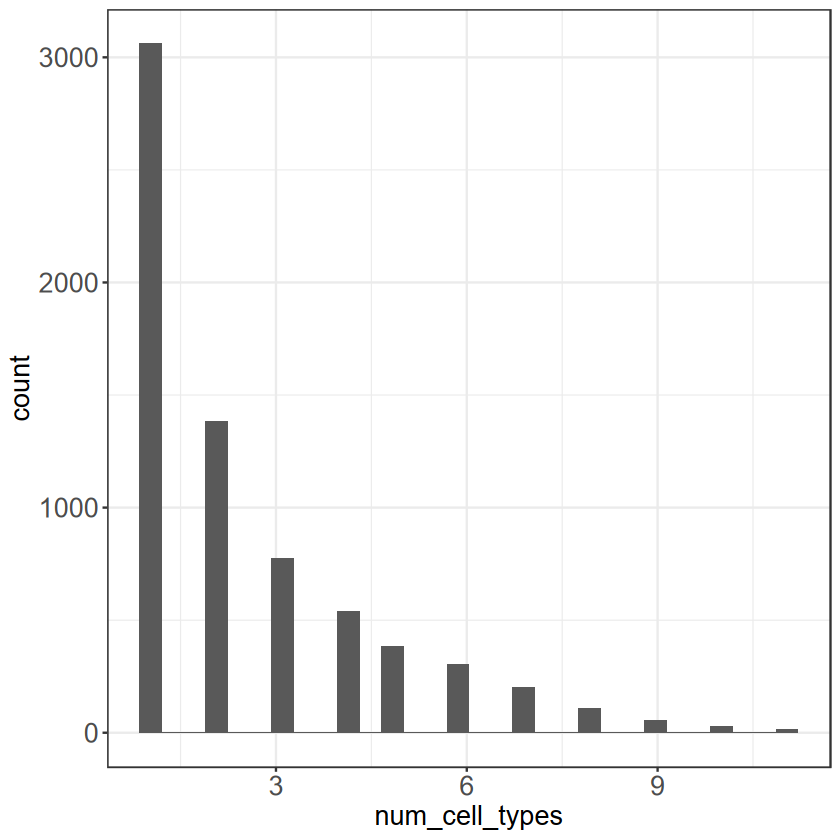

In [21]:
up_DEGs_results_list <- list() 

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = up_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "up"
    
    up_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

In [42]:
up_DEGs_results_list$development %>% head(20)

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
EMC10,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
FBN2,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
HBA1,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
HBA2,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
IGF2BP1,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
IGF2BP3,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
MDK,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
MYL4,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up
MYL7,11,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Lymphoid, LEC, Myeloid, Neuronal, Pericyte, vSMC",development,up


### Perform for down DEGs

[1] "development"
# A tibble: 6,555 × 5
   genes  num_cell_types cell_types                           contrast direction
   <chr>           <int> <chr>                                <chr>    <chr>    
 1 ACTA1              11 Cardiomyocyte, Endocardial, Endothe… develop… down     
 2 NPIPB3             11 Cardiomyocyte, Endocardial, Endothe… develop… down     
 3 NPIPB4             11 Cardiomyocyte, Endocardial, Endothe… develop… down     
 4 S100A1             11 Cardiomyocyte, Endocardial, Endothe… develop… down     
 5 ALDOA              10 Cardiomyocyte, Endocardial, Endothe… develop… down     
 6 ANKHD1             10 Cardiomyocyte, Endocardial, Endothe… develop… down     
 7 APOD               10 Cardiomyocyte, Endocardial, Endothe… develop… down     
 8 CAST               10 Cardiomyocyte, Endocardial, Endothe… develop… down     
 9 CDH19              10 Cardiomyocyte, Endocardial, Endothe… develop… down     
10 CFD                10 Cardiomyocyte, Endocardial, Endothe… develop

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


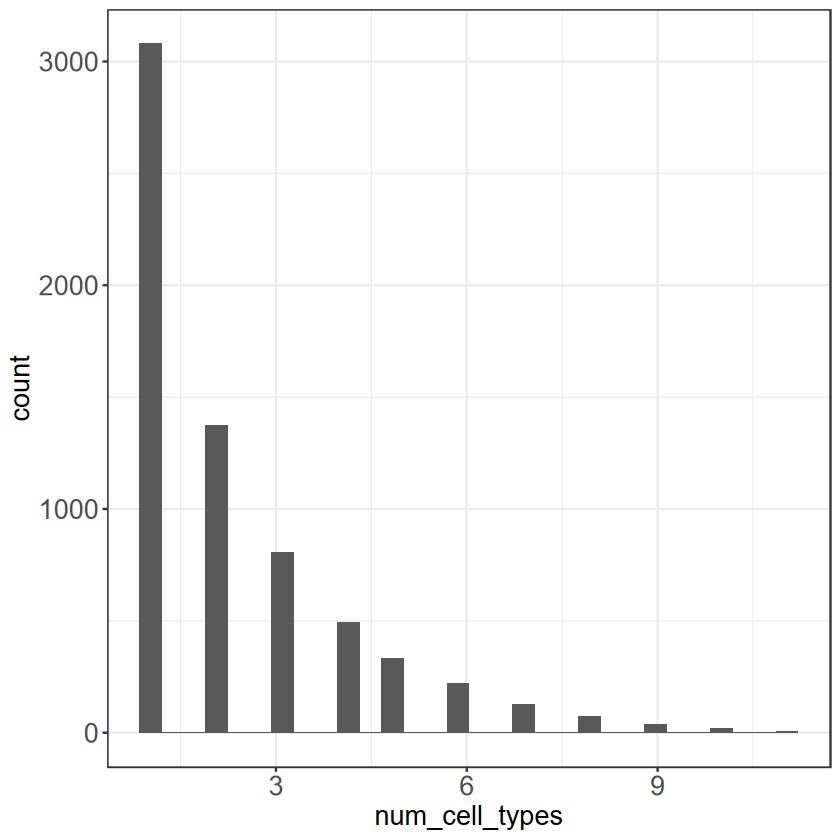

In [30]:
down_DEGs_results_list <- list()

for (contrast in contrasts) {
    print(contrast)
    
    results <- get_common_DEGs_across_cell_types(contrast_of_interest = contrast, DEG_df = down_DEGs_combined_df)
    results_df <- results[[1]]
    results_df$contrast <- contrast
    results_df$direction <- "down"
    
    down_DEGs_results_list[[contrast]] <- results_df
    print(results_df)
    print(results[[2]])
    flush.console()
}

In [50]:
down_genes <- down_DEGs_results_list$development

In [54]:
down_genes$genes %>% head(100)

[1] "ACTA1"       "NPIPB3"      "NPIPB4"      "S100A1"      "ALDOA"      
  [6] "ANKHD1"      "APOD"        "CAST"        "CDH19"       "CFD"        
 [11] "DES"         "DPYD"        "EVA1C"       "IFI27"       "KLF9"       
 [16] "MT-ND2"      "MT-ND3"      "NNMT"        "NPIPB5"      "TCAP"       
 [21] "ZC3H11A"     "ACSL1"       "ADH1B"       "ADRA1A"      "C1QTNF1"    
 [26] "CCND3"       "CEBPB"       "CLIC5"       "CLMN"        "DYNC1I1"    
 [31] "EPAS1"       "FKBP5"       "GABARAPL1"   "GPX3"        "HCLS1"      
 [36] "HSPB6"       "ISCU"        "LRRC8C"      "MIR22HG"     "MT-CO2"     
 [41] "MT-ND1"      "MVP"         "MYOM2"       "NEAT1"       "PDK4"       
 [46] "PLCG2"       "S100A6"      "SP100"       "SPARCL1"     "STEAP4"     
 [51] "SYNM"        "TDRD7"       "TRIM22"      "XIRP2"       "ZBTB16"     
 [56] "ZBTB20"      "ABHD2"       "ABLIM3"      "ADAMTS9-AS2" "AFF1"       
 [61] "ANKRD2"      "APOL3"       "ART4"        "BCL2L1"      "BCL3"       
 [66] "C1QB"        "C1R"         "CALCOCO2"    "CAPS2"       "CD163"      
 [71] "CD59"        "CLEC2B"      "CLIP4"       "CPM"         "CRISPLD2"   
 [76] "CYP1B1"      "DCN"         "DOCK9"       "DRAM1"       "F13A1"      
 [81] "FMO2"        "GBE1"        "GBP2"        "GGT5"        "HIPK2"      
 [86] "IL6R"        "ITPKC"       "JADE2"       "LPL"         "LRRK2"      
 [91] "MAP3K5"      "MB"          "MERTK"       "MGLL"        "MGP"        
 [96] "MRC1"        "MT-CO1"      "MT-ND4L"     "MT1M"        "MT1X"

In [55]:
down_genes[down_genes$genes == "THRB", ]

genes,num_cell_types,cell_types,contrast,direction
<chr>,<int>,<chr>,<chr>,<chr>
THRB,6,"Cardiomyocyte, Endocardial, Endothelial, Epicardial, Fibroblast, Myeloid",development,down


### Produce plots for number of cell types sharing the same DEGs

In [33]:
combined_up_DEGs <- bind_rows(up_DEGs_results_list)
combined_down_DEGs <- bind_rows(down_DEGs_results_list)

combined_all_DEGs <- rbind(combined_up_DEGs, combined_down_DEGs)
combined_all_DEGs$contrast <- factor(combined_all_DEGs$contrast, c("development"))

#### Get the mean number of genes sharing the DEGs

In [34]:
combined_all_DEGs %>% select(num_cell_types, contrast, direction) %>%
group_by(contrast, direction) %>% mutate(mean_cell_types = mean(num_cell_types)) %>% select(contrast, direction, mean_cell_types
) %>% distinct()

contrast,direction,mean_cell_types
<fct>,<chr>,<dbl>
development,up,2.516723
development,down,2.313349


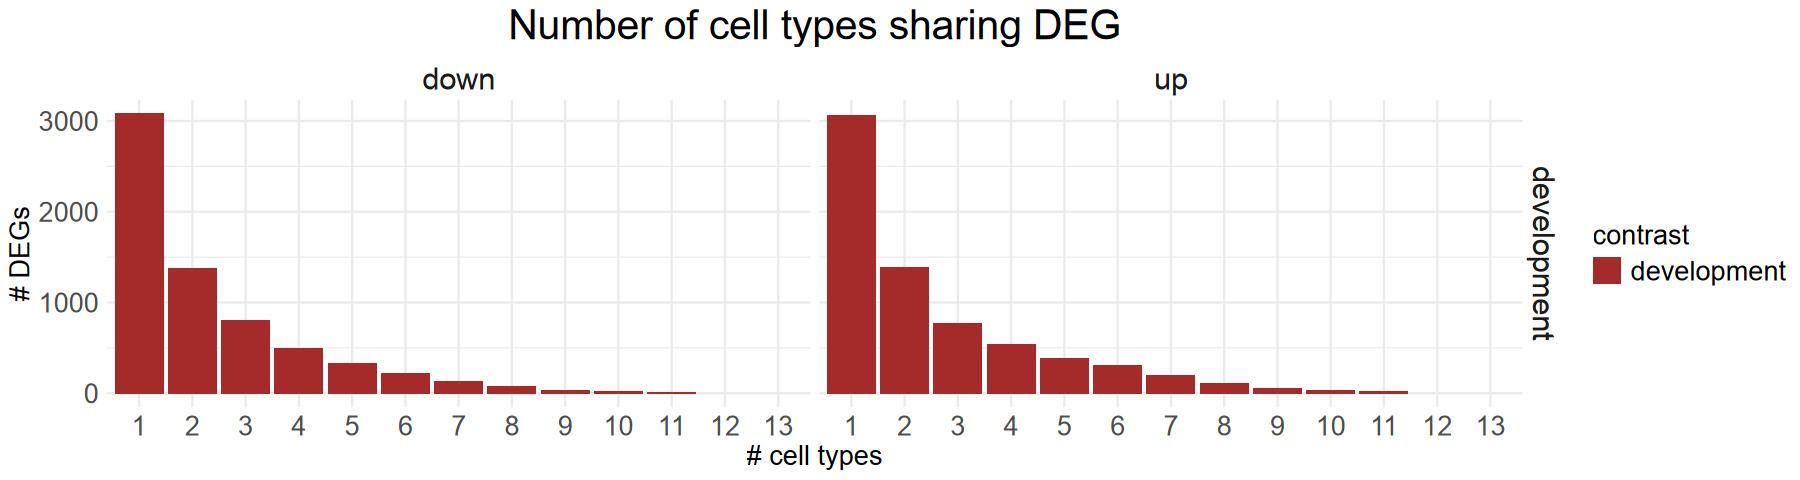

In [39]:
options(repr.plot.width = 15, repr.plot.height = 4)

p3 <- ggplot(data = combined_all_DEGs, mapping = aes(x = factor(num_cell_types), fill = contrast)) + 
  facet_grid(contrast ~ direction, scales = "free_y") + geom_bar() +  scale_x_discrete(limits = as.character(1:13)) +
  theme_minimal() + 
  theme(legend.text = element_text(size = 16), 
        legend.title = element_text(size = 16), 
        plot.title = element_text(size = 24, hjust = 0.5), 
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        strip.text = element_text(size = 18)) +
  labs(title = "Number of cell types sharing DEG", 
       x = "# cell types", y = "# DEGs") +
  scale_fill_manual(values = c("brown", "gray", "#F8766D", "#619CFF"))  # Customize colors for contrast

ggsave(p3, filename = paste0(plots_dir, "04B_number_of_shared_DEGs_across_cell_types.pdf"), width = 15, height = 4)

p3